## Load data from database

In [1]:
import mysql.connector
import numpy as np
import tensorflow as tf

DATABASE_NAME = "mydatabase"

def connect():
    return mysql.connector.connect(
        host="localhost",
        user="root",
        password="root",
        database=DATABASE_NAME
    )

def load_data_from_database(queries: list[str]) -> dict[str, list[dict]]:
    connection = connect()
    cursor = connection.cursor(dictionary=True)

    table_names = []
    try:
        table_names = [query.lower().split("from")[1].split()[0] for query in queries] 
    except Exception as e:
        print("Invalid query!", f"Error: {e}")

    data = {}
    for table_name, query in zip(table_names, queries):
        cursor.execute(query)
        data[table_name] = cursor.fetchall()
    
    cursor.close()
    connection.close()

    return data, table_names

In [2]:
SELLECT_DATA_FROM_ARTICLES = "SELECT id, content, category FROM articles"
SELLECT_DATA_FROM_TFIDF = "SELECT doc_id, word, tfidf_value FROM tfidf"

data, table_names = load_data_from_database([SELLECT_DATA_FROM_ARTICLES, SELLECT_DATA_FROM_TFIDF])

print(f"Number of tables: {len(table_names)}")
for table_name in table_names:
    print(f" + Table: {table_name}, Number of rows: {len(data[table_name])}")

Number of tables: 2
 + Table: articles, Number of rows: 25364
 + Table: tfidf, Number of rows: 1611327


### Visualize the data

In [3]:
import pandas as pd

articles_df = pd.DataFrame(data["articles"])
tfidf_df = pd.DataFrame(data["tfidf"])

print("\nArticles:")
print(articles_df.head())
print("\nTFIDF:")
print(tfidf_df.head())


Articles:
   id                                            content category
0   1  Chiều 5/7, Phó Thủ tướng Chính phủ Lê Thành Lo...  AN SINH
1   2  Góp ý về trợ cấp thất nghiệp tại dự thảo Luật ...  AN SINH
2   3  Niềm vui với người có công\nMức chuẩn trợ cấp ...  AN SINH
3   4  Wang (ngụ tại tỉnh An Huy, miền đông Trung Quố...  AN SINH
4   5  BHXH TPHCM vừa công bố danh sách đơn vị chậm đ...  AN SINH

TFIDF:
   doc_id word  tfidf_value
0       0    0     0.559349
1       0    1     0.002784
2       0   10     0.011217
3       0  107     0.002515
4       0  108     0.020070


## Preprocessing data

In [4]:
from sklearn.model_selection import train_test_split
from collections import defaultdict
from scipy.sparse import lil_matrix # lil_matrix is used to store tfidf values in sparse matrix format, and csr_matrix is used to store the final tfidf matrix
from sklearn.preprocessing import StandardScaler

def preprocess_data(articles_df: pd.DataFrame, tfidf_df: pd.DataFrame, cat_map: dict[str, str] = None) -> tuple:
    '''
    Preprocess data before training model. This function will encode category and split data into train and test set. <br>
    
    Parameters :
    ----------
    **articles_df** : *pd.DataFrame*
        Dataframe containing articles data
    **tfidf_df** : *pd.DataFrame*
        Dataframe containing tfidf data
    
    Returns :
    ----------
    **tuple**
        ***X_train_tfidf***: *csr_matrix*
            Training set of tfidf matrix
        ***X_test_tfidf***: *csr_matrix*
            Test set of tfidf matrix
        ***y_train***: *np.ndarray*
            Training set of labels
        ***y_test***: *np.ndarray*
            Test set of labels
        ***cat2id***: *dict*
            Mapping of category to category_id
    '''
    if cat_map:
        articles_df["category"] = articles_df["category"].map(cat_map)
        # remove rows with category nan (the category is not in cat_map)
        articles_df.dropna(subset=["category"], inplace=True) # 25364 -> 19208
    # create a list mapping category to category_id
    unique_categories = articles_df["category"].unique()
    cat2id = {cat: i for i, cat in enumerate(unique_categories)}
    # label encode category
    y = articles_df["category"].map(cat2id).to_numpy()

    # split data into train and test set
    X_train_ids, X_test_ids, y_train, y_test = \
        train_test_split(articles_df["id"], y, test_size=0.2, random_state=42)

    # create mapping for word and document/article to id
    unique_words = tfidf_df["word"].unique()
    word2id = {word: i for i, word in enumerate(unique_words)}
    doc2id = {doc_id: i for i, doc_id in enumerate(articles_df["id"])}

    # create a dictionary mapping id to a list of tuples (word_index, tfidf_value)
    docid2tfidf = defaultdict(list)
    for doc_id, word, tfidf_value in tfidf_df.values:
        if doc_id in doc2id:
            docid2tfidf[doc_id].append((word2id[word], tfidf_value))
    
    num_words = len(word2id) # vocabulary size
    num_docs = len(doc2id) # number of documents/articles
    # create a lil matrix to store tfidf values
    X = lil_matrix((num_docs, num_words))
    for doc_id, values in docid2tfidf.items():
        mapped_doc_id = doc2id[doc_id]
        for word_index, tfidf_value in values:
            X[mapped_doc_id, word_index] = tfidf_value
    
    # convert lil matrix to csr matrix
    X = X.tocsr()

    # get the indices of train and test set/map doc_id to id
    train_indices = [doc2id[doc_id] for doc_id in X_train_ids]
    test_indices = [doc2id[doc_id] for doc_id in X_test_ids]

    X_train_tfidf = X[train_indices]
    X_test_tfidf = X[test_indices]
    
    # scale data
    scaler = StandardScaler(with_mean=False)
    X_train_tfidf = scaler.fit_transform(X_train_tfidf)
    X_test_tfidf = scaler.transform(X_test_tfidf)

    return X_train_tfidf, X_test_tfidf, y_train, y_test, cat2id, scaler

In [5]:
category_mapping = {
    "Chính trị": "Chính trị",
    "CHÍNH TRỊ": "Chính trị",
    "Thời sự": "Chính trị",
    "THỜI SỰ": "Chính trị",
    "Xã hội": "Xã hội",
    "XÃ HỘI": "Xã hội",
    "Đời sống": "Xã hội",
    "ĐỜI SỐNG": "Xã hội",
    "AN SINH": "Xã hội",
    "LAO ĐỘNG - VIỆC LÀM": "Xã hội",
    "TÌNH YÊU - GIỚI TÍNH": "Xã hội",
    "KHCN": "KHCN",
    "KHOA HỌC - CÔNG NGHỆ": "KHCN",
    "SỨC MẠNH SỐ": "KHCN",
    "Số hóa": "KHCN",
    "CÔNG NGHIỆP HỖ TRỢ": "KHCN",
    "Kinh tế": "Kinh tế",
    "KINH DOANH": "Kinh tế",
    "Kinh doanh": "Kinh tế",
    "THỊ TRƯỜNG - TIÊU DÙNG": "Kinh tế",
    "BẤT ĐỘNG SẢN": "Kinh tế",
    "Bất động sản": "Kinh tế",
    "THẾ GIỚI": "Thế giới",
    "Thế giới": "Thế giới",
    "Văn hóa": "Văn hóa",
    "VĂN HÓA": "Văn hóa",
    "GIẢI TRÍ": "Giải trí",
    "Giải trí": "Giải trí",
    "DU LỊCH": "Du lịch",
    "Du lịch": "Du lịch",
    "GIÁO DỤC": "Giáo dục",
    "Giáo dục": "Giáo dục",
    "SỨC KHỎE": "Sức khỏe",
    "Sức khỏe": "Sức khỏe",
    "Các bệnh": "Sức khỏe",
    "PHÁP LUẬT": "Pháp luật",
    "Pháp luật": "Pháp luật",
    "THỂ THAO": "Thể thao",
    "Thể thao": "Thể thao"
}
X_train_tfidf, X_test_tfidf, y_train, y_test, cat2id, scaler = \
preprocess_data(articles_df, tfidf_df, category_mapping)

In [6]:
X_train_tfidf.shape, X_test_tfidf.shape

((15366, 189), (3842, 189))

In [7]:
X_train_tfidf.toarray()[:5], y_train[:5]

(array([[2.17821135, 0.14824894, 0.90839386, 0.62032971, 1.93451509,
         1.48843589, 2.58410648, 0.47208298, 0.67696752, 1.75851749,
         0.        , 1.55605692, 1.35907905, 1.3912663 , 2.40461627,
         0.        , 2.26879314, 1.40490548, 1.50307096, 1.31064081,
         4.21530201, 2.31790553, 1.33317931, 1.86528447, 2.02834213,
         0.74335801, 1.94698914, 1.12630616, 1.92970252, 1.69326765,
         2.17472778, 0.34443725, 0.806783  , 0.99830495, 2.37912728,
         0.        , 0.35772444, 1.85462281, 2.19990556, 1.08471064,
         2.26806295, 0.96865295, 2.89360674, 1.62025411, 2.35215313,
         2.17117252, 2.43616476, 2.62237247, 1.64802034, 1.25915124,
         1.67693693, 1.99725697, 3.05972207, 0.39121619, 2.33059919,
         1.78215777, 1.42137173, 3.47500568, 0.41912481, 0.77123282,
         3.85351176, 1.33155021, 1.52089093, 0.36511333, 0.76889055,
         1.11205657, 2.05359274, 1.32690491, 0.        , 1.32766623,
         0.82243881, 2.34770692, 0

### Evaluate the model

In [36]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report

def evaluate_model(model, X_test, y_test, cat2id):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    report = classification_report(y_test, y_pred, target_names=cat2id.keys())
    report_dict = classification_report(y_test, y_pred, target_names=cat2id.keys(), output_dict=True)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 score (Macro): {f1:.4f}")
    print(report)
    return accuracy, f1, report_dict

## Train with TF-IDF method

### Train with LSTM model

#### Pytorch

In [60]:
# LSTM model with pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.sparse import csr_matrix

class LSTM_Model(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(LSTM_Model, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        x = self.embedding(x)
        print(f"x shape: {x.shape}, h0 shape: {h0.shape}, c0 shape: {c0.shape}")
        out, _ = self.lstm(x, (h0, c0))
        print(f"out shape: {out.shape}")
        out = self.fc(out[:, -1, :])
        out = self.softmax(out)

        return out

class LSTM_Model_wo_Embedding(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2, bidirectional=False):
        super(LSTM_Model_wo_Embedding, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout, bidirectional=bidirectional)
        self.fc = nn.Linear(hidden_size * (bidirectional + 1), num_classes)
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x): # x shape: (batch_size, input_size)
        # h0/c0 shape: (num_layers, batch_size, hidden_size)
        num_lays_actual = self.num_layers * (self.lstm.bidirectional + 1)
        h0 = torch.zeros(num_lays_actual, x.size(0), self.hidden_size).to(x.device) 
        c0 = torch.zeros(num_lays_actual, x.size(0), self.hidden_size).to(x.device) 
        x = x.unsqueeze(1) # x shape: (batch_size, seq_len=1, input_size)
        out, _ = self.lstm(x, (h0, c0)) # out shape: (batch_size, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])
        out = self.softmax(out)

        return out
    
class TfIdfDataset(TensorDataset):
    def __init__(self, X, y):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if isinstance(X, csr_matrix):
            X = X.toarray()
        X = torch.tensor(X, dtype=torch.float32).to(device)
        y = torch.tensor(y, dtype=torch.long).to(device)
        super(TfIdfDataset, self).__init__(X, y)
    
    def __getitem__(self, index):
        return self.tensors[0][index], self.tensors[1][index]
    
def train_model(model, X_train, y_train, X_test, y_test, cat2id, num_epochs=10, batch_size=32, learning_rate=0.001, early_stopping=-1, check_converge=True, verbose=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training process is running on `{device}`")

    model.to(device)

    train_dataset = TfIdfDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataset = TfIdfDataset(X_test, y_test)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    history = {"loss": [], "accuracy": [], "f1": []}
    best_model = None
    is_stopped = False
    for epoch in range(num_epochs):
        model.train()
        for i, (X_batch, y_batch) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            X_test, y_test = test_dataset[:]
            outputs = model(X_test)
            _, predicted = torch.max(outputs, 1)
            accuracy = (predicted == y_test).sum().item() / y_test.size(0)
            f1 = f1_score(y_test.cpu().numpy(), predicted.cpu().numpy(), average="macro")
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}, F1 score: {f1:.4f}")
            history["loss"].append(loss.item())
            history["accuracy"].append(accuracy)
            history["f1"].append(f1)
            if f1 > max(history["f1"]):
                best_model = model.state_dict().copy()

            if early_stopping > 0 and len(history["f1"]) > early_stopping:
                # check if the last `early_stopping` f1 scores are not improved
                is_stopped = all([f1 <= f1_score for f1_score in history["f1"][-early_stopping:]])
                if is_stopped:
                    print(f"Early stopping at epoch {epoch+1}")
                    break
            # check if the model is converged by std of f1 score
            if check_converge and len(history["f1"]) > 200:
                if np.std(history["f1"][-50:]) < 0.03:
                    print(f"Converged at epoch {epoch+1}")
                    break
            

    return model, history, best_model

In [10]:
X_train_tfidf.shape, y_train.shape # (20291, 1)

((15366, 189), (15366,))

In [11]:
EPOCHS = 1000

lstm_model = LSTM_Model_wo_Embedding(input_size=X_train_tfidf.shape[1], hidden_size=128, num_layers=2, num_classes=len(cat2id), bidirectional=True)
lstm_model, his, best_model = train_model(lstm_model, X_train_tfidf, y_train, X_test_tfidf, y_test, cat2id, num_epochs=EPOCHS)

Training process is running on `cuda`
Epoch 1/1000, Loss: 2.2761, Accuracy: 0.2686, F1 score: 0.0799
Epoch 2/1000, Loss: 2.4227, Accuracy: 0.3001, F1 score: 0.1170
Epoch 3/1000, Loss: 2.3747, Accuracy: 0.3121, F1 score: 0.1293
Epoch 4/1000, Loss: 2.5104, Accuracy: 0.3040, F1 score: 0.1409
Epoch 5/1000, Loss: 2.2716, Accuracy: 0.3261, F1 score: 0.1713
Epoch 6/1000, Loss: 2.1279, Accuracy: 0.3235, F1 score: 0.1736
Epoch 7/1000, Loss: 2.5337, Accuracy: 0.3238, F1 score: 0.1723
Epoch 8/1000, Loss: 2.0471, Accuracy: 0.3355, F1 score: 0.1851
Epoch 9/1000, Loss: 2.1029, Accuracy: 0.3225, F1 score: 0.1714
Epoch 10/1000, Loss: 1.7899, Accuracy: 0.3222, F1 score: 0.1890
Epoch 11/1000, Loss: 2.0142, Accuracy: 0.3329, F1 score: 0.1886
Epoch 12/1000, Loss: 2.2996, Accuracy: 0.3329, F1 score: 0.1899
Epoch 13/1000, Loss: 2.4440, Accuracy: 0.3363, F1 score: 0.1844
Epoch 14/1000, Loss: 2.4368, Accuracy: 0.3365, F1 score: 0.1900
Epoch 15/1000, Loss: 1.9517, Accuracy: 0.3404, F1 score: 0.1931
Epoch 16/10

Max accuracy: 0.3904, Max f1 score: 0.3361


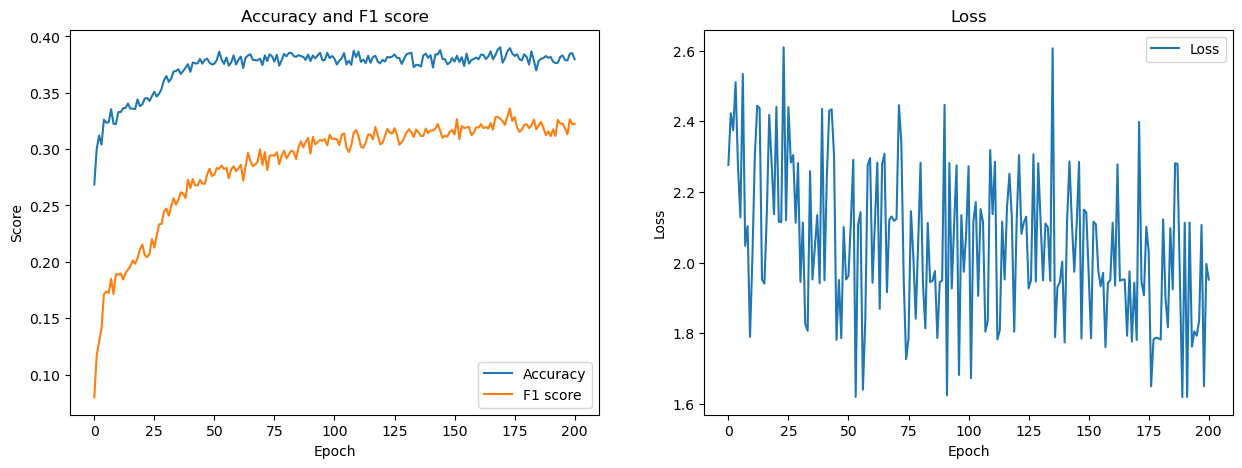

In [12]:
# plot accuracy and loss / f1 score
import matplotlib.pyplot as plt

def plot_history(history):
    print(f"Max accuracy: {max(history['accuracy']):.4f}, Max f1 score: {max(history['f1']):.4f}")
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    ax[0].plot(history["accuracy"], label="Accuracy")
    ax[0].plot(history["f1"], label="F1 score")
    ax[0].set_title("Accuracy and F1 score")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Score")
    ax[0].legend()

    ax[1].plot(history["loss"], label="Loss")
    ax[1].set_title("Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend()

    plt.show()

plot_history(his)

### Train with Naive Bayes model

In [65]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
# csr_matrix
from scipy.sparse import lil_matrix, csr_matrix
from sklearn.pipeline import Pipeline

def train_naive_bayes(X_train: csr_matrix, y_train: np.ndarray, cat2id) -> MultinomialNB:
    '''
    Train a Naive Bayes model using the training set
    
    Parameters :
    ----------
    **X_train** : *csr_matrix*
        Training set of tfidf matrix
    **y_train** : *np.ndarray*
        Training set of labels
    
    Returns :
    ----------
    **MultinomialNB**
        Trained Naive Bayes model
    '''
    pipeline = Pipeline([
        ('nb', MultinomialNB())
    ])
    param_grid = {
        'nb__alpha': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], # smoothing parameter
        'nb__fit_prior': [True, False], # whether to learn class prior probabilities or not
        'nb__force_alpha': [True, False] # whether to add alpha to data
    }

    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        verbose=2,
        scoring='f1_macro'
    )

    print("Training Naive Bayes model...")
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    print("Best hyperparameters: ", grid_search.best_params_)
    return best_model

In [18]:
nb_model = train_naive_bayes(X_train_tfidf, y_train, category_mapping)

Training Naive Bayes model...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best hyperparameters:  {'nb__alpha': 0.1, 'nb__fit_prior': True, 'nb__force_alpha': True}


In [37]:
nb_accuracy, nb_f1, nb_report = evaluate_model(nb_model, X_test_tfidf, y_test, cat2id)

Accuracy: 0.2798
F1 score (Macro): 0.2141
              precision    recall  f1-score   support

      Xã hội       0.46      0.49      0.48       619
     Kinh tế       0.24      0.55      0.34       665
     Du lịch       0.44      0.15      0.23       284
    Giáo dục       0.35      0.25      0.29       259
    Giải trí       0.17      0.35      0.23       245
     Văn hóa       0.19      0.33      0.24        78
        KHCN       0.44      0.06      0.10       398
    Sức khỏe       0.18      0.01      0.02       247
   Pháp luật       0.37      0.31      0.34       299
    Thể thao       0.11      0.08      0.10       249
    Thế giới       0.14      0.00      0.01       285
   Chính trị       0.20      0.23      0.21       214

    accuracy                           0.28      3842
   macro avg       0.28      0.23      0.21      3842
weighted avg       0.30      0.28      0.25      3842



### Save the models

In [21]:
# save best model to file without joblib, pickle
import torch
DIR = "./saved_models"
torch.save(best_model, f"{DIR}/best_lstm_model.pth")
torch.save(lstm_model, f"{DIR}/lstm_model.pth")
torch.save(nb_model, f"{DIR}/nb_model.pth")

# save best model to file with joblib, pickle
import joblib
joblib.dump(nb_model, f"{DIR}/nb_model.joblib")

['./saved_models/nb_model.joblib']

In [34]:
import json
def save_training_result_to_database(name: str, accuracy: float, f1: float, report=None):
    connection = connect()
    cursor = connection.cursor()

    CREATE_TABLE = '''
    CREATE TABLE IF NOT EXISTS training_result (
        id INT AUTO_INCREMENT PRIMARY KEY,
        name VARCHAR(255) NOT NULL,
        accuracy FLOAT NOT NULL,
        f1 FLOAT NOT NULL,
        report TEXT,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
    '''
    cursor.execute(CREATE_TABLE)
    report = json.dumps(report)

    cursor.execute('''
    INSERT INTO training_result (name, accuracy, f1, report)
    VALUES (%s, %s, %s, %s)
    ''', (name, accuracy, f1, report))
    

    connection.commit()
    cursor.close()
    connection.close()

In [39]:
save_training_result_to_database("LSTM", his["accuracy"][-1], his["f1"][-1])
save_training_result_to_database("Naive Bayes", nb_accuracy, nb_f1, nb_report)

## SBERT

### Vectorize the preprocessed data with SBERT

In [31]:
# using `sbert` instead of `tfidf` to train model
from sentence_transformers import SentenceTransformer

def encode_sbert_model(processed_texts_df: pd.DataFrame, cat2id: dict[str, int], model_name: str = 'paraphrase-MiniLM-L6-v2') -> SentenceTransformer:
    '''
    Train a sentence transformer model using the training set
    
    Parameters :
    ----------
    **articles_df** : *pd.DataFrame*
        Dataframe containing articles data
    **cat2id** : *dict*
        Mapping of category to category_id
    **model_name** : *str*
        Name of the sentence transformer model
    
    Returns :
    ----------
    **SentenceTransformer**
        Trained sentence transformer model and training set
    '''
    model = SentenceTransformer(model_name)
    X = model.encode(processed_texts_df["texts"].values)
    y = processed_texts_df["catcategory"].map(cat2id).to_numpy()
    
    return model, (X, y)

Select the preprocessed data from the database

In [22]:
SELLECT_DATA_FROM_PROCESSED_TEXTS = "SELECT * FROM processed_texts"

data, table_names = load_data_from_database([SELLECT_DATA_FROM_PROCESSED_TEXTS])

In [24]:
processed_texts_df = pd.DataFrame(data["processed_texts"])

print("\nProcessed texts:")
print(processed_texts_df.head())


Processed texts:
   id                                              texts catcategory
0   1  phó_thủ_tướng thăm tặng quà mẹ việt_nam anh_hù...      Xã hội
1   2  quy_định rõ trường_hợp hưởng bảo_hiểm_thất_ngh...      Xã hội
2   3  trợ_cấp người công tăng mức cao nhất thương_bi...      Xã hội
3   4  xôn_xao clip bố dùng máy_bay chở con_gái về qu...      Xã hội
4   5  doanh_nghiệp nợ bảo_hiểm xã_hội cao nhất vượt ...      Xã hội


Encode the data with SBERT

In [40]:
sbert, (X_sbert, y_sbert) = encode_sbert_model(processed_texts_df, cat2id)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.73k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

c:\Users\Phu Nguyen\AppData\Roaming\anaconda3\envs\cuda_conda_env\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

c:\Users\Phu Nguyen\AppData\Roaming\anaconda3\envs\cuda_conda_env\lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [51]:
X_sbert.shape, y_sbert.shape

((19208, 384), (19208,))

In [68]:
X_sbert[:5], y_sbert[:5]

(array([[-0.37191504,  0.87461674,  0.07918644, ..., -0.26775128,
         -0.40596062,  0.48818454],
        [-0.30143672,  0.9820508 ,  0.07877803, ..., -0.17924228,
         -0.68262154,  0.42859358],
        [-0.5157678 ,  0.6411671 ,  0.0419274 , ..., -0.5220461 ,
         -0.3606347 ,  0.30664504],
        [-0.7000105 ,  0.3848567 ,  0.37234512, ..., -0.16220844,
         -0.35815787,  0.16616493],
        [-0.5584759 ,  1.1089946 , -0.12009078, ..., -0.26474723,
         -0.33565056,  0.19946048]], dtype=float32),
 array([0, 0, 0, 0, 0], dtype=int64))

Standardize the data

In [69]:
scaler_sbert = StandardScaler(with_mean=False)
X_sbert = scaler_sbert.fit_transform(X_sbert)

In [70]:
X_sbert[:5], y_sbert[:5]

(array([[-2.1681893 ,  4.907904  ,  0.56364685, ..., -1.671263  ,
         -2.6850755 ,  3.1992714 ],
        [-1.757315  ,  5.5107694 ,  0.5607398 , ..., -1.1188033 ,
         -4.5149465 ,  2.8087475 ],
        [-3.0068219 ,  3.5979035 ,  0.2984381 , ..., -3.2585328 ,
         -2.3852842 ,  2.0095694 ],
        [-4.0809193 ,  2.15962   ,  2.6503422 , ..., -1.0124805 ,
         -2.3689022 ,  1.0889462 ],
        [-3.2558014 ,  6.2231135 , -0.8548028 , ..., -1.6525122 ,
         -2.2200358 ,  1.3071455 ]], dtype=float32),
 array([0, 0, 0, 0, 0], dtype=int64))

Slip the data into train and test set

In [63]:
# split data into train and test set
X_train_sbert, X_test_sbert, y_train_sbert, y_test_sbert = \
    train_test_split(X_sbert, y_sbert, test_size=0.2, random_state=42)

### Train with LSTM model

In [64]:
lstm_model_sbert = LSTM_Model_wo_Embedding(input_size=X_sbert.shape[1], hidden_size=128, num_layers=2, num_classes=len(cat2id), bidirectional=True)
lstm_model_sbert, his_sbert, _ = train_model(lstm_model_sbert, X_train_sbert, y_train_sbert, X_test_sbert, y_test_sbert, cat2id, num_epochs=EPOCHS)

Training process is running on `cuda`
Epoch 1/1000, Loss: 2.0347, Accuracy: 0.3909, F1 score: 0.2319
Epoch 2/1000, Loss: 2.3179, Accuracy: 0.4016, F1 score: 0.2429
Epoch 3/1000, Loss: 1.7838, Accuracy: 0.4118, F1 score: 0.2638
Epoch 4/1000, Loss: 1.7913, Accuracy: 0.4477, F1 score: 0.3211
Epoch 5/1000, Loss: 1.8793, Accuracy: 0.4560, F1 score: 0.3295
Epoch 6/1000, Loss: 1.9707, Accuracy: 0.4800, F1 score: 0.3577
Epoch 7/1000, Loss: 2.1547, Accuracy: 0.4654, F1 score: 0.3523
Epoch 8/1000, Loss: 2.3094, Accuracy: 0.4948, F1 score: 0.3852
Epoch 9/1000, Loss: 2.2489, Accuracy: 0.5003, F1 score: 0.4014
Epoch 10/1000, Loss: 2.0628, Accuracy: 0.5432, F1 score: 0.4732
Epoch 11/1000, Loss: 1.6324, Accuracy: 0.5666, F1 score: 0.5007
Epoch 12/1000, Loss: 1.8281, Accuracy: 0.5791, F1 score: 0.5062
Epoch 13/1000, Loss: 1.9834, Accuracy: 0.5903, F1 score: 0.5181
Epoch 14/1000, Loss: 1.9451, Accuracy: 0.5773, F1 score: 0.5133
Epoch 15/1000, Loss: 2.1195, Accuracy: 0.5875, F1 score: 0.5190
Epoch 16/10

Max accuracy: 0.6577, Max f1 score: 0.6250


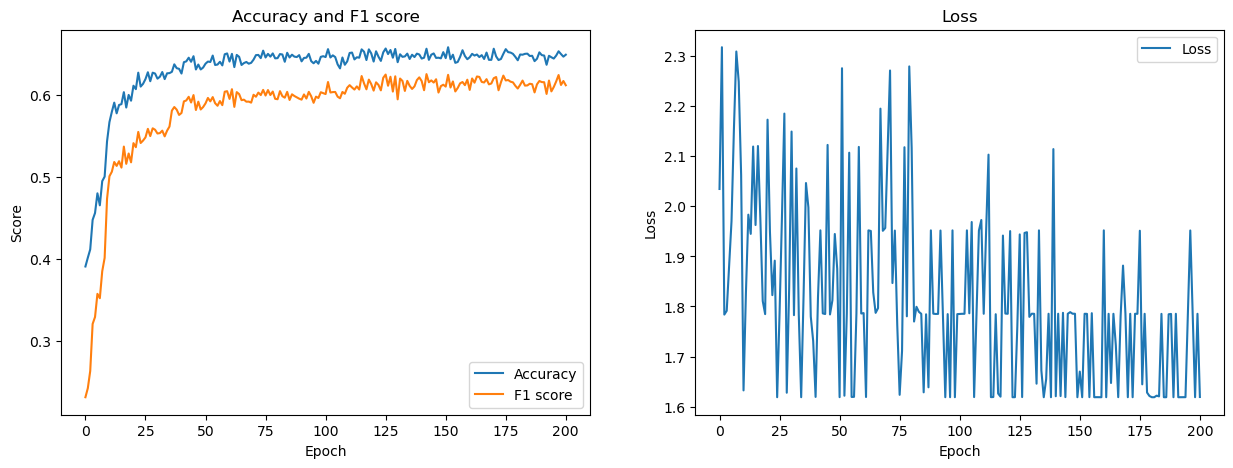

In [66]:
# plot accuracy and loss / f1 score
plot_history(his_sbert)

### Train with Naive Bayes model

In [73]:
pipeline = Pipeline([
        ('nb', GaussianNB())
    ])
print(pipeline.get_params().keys())

dict_keys(['memory', 'steps', 'verbose', 'nb', 'nb__priors', 'nb__var_smoothing'])


In [81]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.model_selection import GridSearchCV
def train_nb_negative_values(X_train: np.ndarray, y_train: np.ndarray, cat2id) -> MultinomialNB:
    '''
    Train a Naive Bayes model using the training set
    
    Parameters :
    ----------
    **X_train** : *np.ndarray*
        Training set of tfidf matrix
    **y_train** : *np.ndarray*
        Training set of labels
    
    Returns :
    ----------
    **MultinomialNB**
        Trained Naive Bayes model
    '''
    pipeline = Pipeline([
        ('nb', GaussianNB())
    ])
    param_grid = {
        'nb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
    }

    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        verbose=2,
        scoring='f1_macro'
    )

    print("Training Naive Bayes model...")
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    print("Best hyperparameters: ", grid_search.best_params_)
    return best_model

nb_model_sbert = train_nb_negative_values(X_train_sbert, y_train_sbert, category_mapping)

Training Naive Bayes model...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best hyperparameters:  {'nb__var_smoothing': 0.001}


In [82]:
nb_accuracy_sbert, nb_f1_sbert, nb_report_sbert = evaluate_model(nb_model_sbert, X_test_sbert, y_test_sbert, cat2id)

Accuracy: 0.4425
F1 score (Macro): 0.4379
              precision    recall  f1-score   support

      Xã hội       0.46      0.32      0.38       619
     Kinh tế       0.54      0.33      0.41       665
     Du lịch       0.36      0.29      0.32       284
    Giáo dục       0.41      0.58      0.48       259
    Giải trí       0.30      0.35      0.33       245
     Văn hóa       0.13      0.31      0.18        78
        KHCN       0.45      0.45      0.45       398
    Sức khỏe       0.41      0.36      0.39       247
   Pháp luật       0.48      0.60      0.53       299
    Thể thao       0.63      0.72      0.67       249
    Thế giới       0.86      0.73      0.79       285
   Chính trị       0.25      0.51      0.34       214

    accuracy                           0.44      3842
   macro avg       0.44      0.46      0.44      3842
weighted avg       0.47      0.44      0.45      3842



### Save the models

In [84]:
# save best model to file without joblib, pickle
import torch
DIR = "./saved_models"
torch.save(lstm_model_sbert, f"{DIR}/lstm_sbert_model.pth")
torch.save(nb_model_sbert, f"{DIR}/nb_sbert_model.pth")

# save best model to file with joblib, pickle
import joblib
joblib.dump(nb_model_sbert, f"{DIR}/nb_sbert_model.joblib")

['./saved_models/nb_sbert_model.joblib']

In [85]:
save_training_result_to_database("LSTM SBERT", his_sbert["accuracy"][-1], his_sbert["f1"][-1])
save_training_result_to_database("Naive Bayes SBERT", nb_accuracy_sbert, nb_f1_sbert, nb_report_sbert)